# Google Local Data (2021) - Exploratory Analysis

Tasks 1-3: NYC Restaurant Corpus - Data Quality Audit - Temporal Coverage

**File loading strategy:** `meta-New_York.json.gz` (272,189 NY state businesses) is loaded
in full and filtered in memory. `review-New_York_10.json.gz` (18,661,975 reviews, 10-core)
is streamed in 500,000-row chunks filtered to the NYC restaurant `gmap_id` set from Task 1.
A single streaming pass through the review file feeds both Task 2 and Task 3.

| # | Task | Phase | Priority |
|---|---|---|---|
| 1 | NYC Restaurant Corpus Definition | Foundation | P0 |
| 2 | Data Quality Audit | Foundation | P0 |
| 3 | Temporal Coverage & TLC Alignment | Foundation | P0 |

In [1]:
from pathlib import Path
import gzip
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

RAW  = Path('../data/raw/googlelocal')
PROC = Path('../data/processed')
PROC.mkdir(parents=True, exist_ok=True)

REVIEW_FILE = RAW / 'review-New_York_10.json.gz'
META_FILE   = RAW / 'meta-New_York.json.gz'

CHUNK = 50_000

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Task 1 - NYC Restaurant Corpus Definition

Filter `meta-New_York.json.gz` to businesses physically in NYC with at least one food/restaurant
category tag. This corpus drives all downstream filtering: no review data is loaded without
first intersecting against the resulting `gmap_id` set.

**Geographic filter:** Bounding box - latitude [40.45, 40.92], longitude [-74.26, -73.70].
Covers all five boroughs. The `state` field in metadata is business hours status
(e.g. `"Closes soon"`), NOT a US state abbreviation - coordinates are the only reliable
geographic signal.

**Category filter:** Any tag containing `"restaurant"` (case-insensitive) covers all
cuisine-specific variants. An explicit seed set covers non-`restaurant`-named food venues.
Top-30 tags explored first to calibrate the seed before applying the filter.

In [2]:
# NYC bounding box covering all five boroughs
LAT_MIN, LAT_MAX =  40.45,  40.92
LON_MIN, LON_MAX = -74.26, -73.70

print('Loading NY state metadata ...')
meta_chunks = []
with gzip.open(META_FILE, 'rb') as f:
    for chunk in pd.read_json(f, lines=True, chunksize=CHUNK):
        meta_chunks.append(chunk)
meta_all = pd.concat(meta_chunks, ignore_index=True)
print(f'Total NY state businesses:     {len(meta_all):,}')

# Bounding box filter
in_bbox = (
    meta_all['latitude'].between(LAT_MIN, LAT_MAX) &
    meta_all['longitude'].between(LON_MIN, LON_MAX)
)
meta_bbox = meta_all[in_bbox].copy().reset_index(drop=True)
print(f'Within NYC bounding box:       {len(meta_bbox):,}')
del meta_all

Loading NY state metadata ...
Total NY state businesses:     272,189
Within NYC bounding box:       116,122


In [3]:
# Explode category lists to find top tags among bbox-filtered businesses.
# Review this output to confirm the food seed set in the next cell is complete.
cat_counts: dict[str, int] = {}
for cats in meta_bbox['category'].dropna():
    if isinstance(cats, list):
        for c in cats:
            cat_counts[c] = cat_counts.get(c, 0) + 1

cat_series = pd.Series(cat_counts, name='count').sort_values(ascending=False)
print(f'Distinct category tags in NYC bbox businesses: {len(cat_series):,}')
print()
print('Top-30 category tags (review before adjusting food seed in next cell):')
display(cat_series.head(30).to_frame())

Distinct category tags in NYC bbox businesses: 3,269

Top-30 category tags (review before adjusting food seed in next cell):


,count
Restaurant,8799
Bar,4234
Delivery Restaurant,3618
Coffee shop,3091
Fast food restaurant,2814
Cafe,2766
Beauty salon,2623
Grocery store,2552
Bakery,2503
Deli,2399


In [4]:
# Food seed: substring 'restaurant' captures all cuisine-specific variants
# (e.g. 'Italian restaurant', 'Chinese restaurant', 'Pizza restaurant', etc.).
# FOOD_EXPLICIT covers common food venues whose name does not contain 'restaurant'.
# Adjust after reviewing the top-30 output above.
FOOD_EXPLICIT = {
    'food', 'cafe', 'coffee shop', 'bar', 'pub', 'brewery',
    'bakery', 'donut shop', 'ice cream shop', 'sandwich shop',
    'bagel shop', 'juice bar', 'wine bar', 'cocktail bar',
    'diner', 'bistro', 'brasserie', 'food court', 'food truck',
    'meal delivery', 'meal takeaway', 'catering food and drink supplier',
}

def is_food_venue(cats) -> bool:
    if not isinstance(cats, list):
        return False
    for c in cats:
        c_lo = c.lower()
        if 'restaurant' in c_lo or c_lo in FOOD_EXPLICIT:
            return True
    return False

food_mask = meta_bbox['category'].map(is_food_venue)
nyc_meta  = meta_bbox[food_mask].copy().reset_index(drop=True)
print(f'After food category filter:    {len(nyc_meta):,}')

# Borough approximation from coordinates (approximate - no shapefile at this stage)
lat = nyc_meta['latitude']
lon = nyc_meta['longitude']
borough = pd.Series('Queens', index=nyc_meta.index, dtype=object)
borough[lon < -74.04] = 'Staten Island'
borough[(lat > 40.796) & (lon < -73.765)] = 'Bronx'
borough[(lon < -73.875) & (lat < 40.745)] = 'Brooklyn'
borough[(lon > -73.925) & (lat > 40.695)] = 'Manhattan'
nyc_meta['borough'] = borough.values

# Decision gate
if len(nyc_meta) < 5_000:
    print('GATE FAILED: fewer than 5,000 NYC restaurants - widen the food filter')
else:
    print(f'Gate passed: {len(nyc_meta):,} NYC restaurants (threshold: 5,000)')

After food category filter:    32,364
Gate passed: 32,364 NYC restaurants (threshold: 5,000)


In [5]:
borough_counts = nyc_meta['borough'].value_counts()

summary_t1 = pd.DataFrame({
    'metric': [
        'Total NYC restaurants',
        'With price tier',
        'Null price tier',
        'Null avg_rating',
        'Null coordinates',
    ],
    'count': [
        len(nyc_meta),
        nyc_meta['price'].notna().sum(),
        nyc_meta['price'].isna().sum(),
        nyc_meta['avg_rating'].isna().sum(),
        (nyc_meta['latitude'].isna() | nyc_meta['longitude'].isna()).sum(),
    ],
})
summary_t1['share_%'] = (summary_t1['count'] / len(nyc_meta) * 100).round(1)
display(summary_t1.set_index('metric'))

print('\nPrice tier distribution:')
price_dist = (
    nyc_meta['price']
    .fillna('null')
    .value_counts()
    .reindex(['$', '$$', '$$$', '$$$$', 'null'], fill_value=0)
)
display(price_dist.rename('count').to_frame())

,count,share_%
metric,,
Total NYC restaurants,32364,100.0
With price tier,21494,66.4
Null price tier,10870,33.6
Null avg_rating,0,0.0
Null coordinates,0,0.0



Price tier distribution:


,count
price,
$,9696
$$,10335
$$$,1069
$$$$,227
null,10870


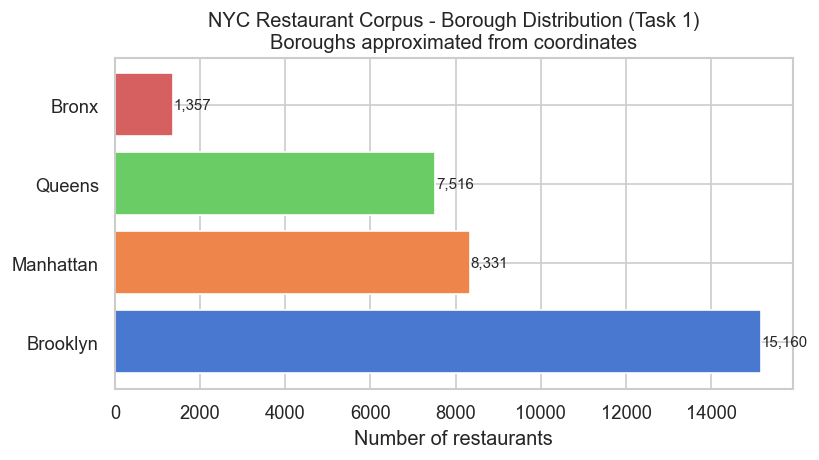

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
pal  = sns.color_palette('muted', n_colors=len(borough_counts))
bars = ax.barh(borough_counts.index, borough_counts.values, color=pal)
for bar, val in zip(bars, borough_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of restaurants')
ax.set_title(
    'NYC Restaurant Corpus - Borough Distribution (Task 1)\n'
    'Boroughs approximated from coordinates'
)
plt.tight_layout()
plt.show()

In [7]:
NYC_GMAP_IDS: set = set(nyc_meta['gmap_id'])
with open(PROC / 'nyc_restaurant_gmap_ids.pkl', 'wb') as f:
    pickle.dump(NYC_GMAP_IDS, f)
print(f'Saved {len(NYC_GMAP_IDS):,} gmap_ids -> {PROC / "nyc_restaurant_gmap_ids.pkl"}')

Saved 32,283 gmap_ids -> ../data/processed/nyc_restaurant_gmap_ids.pkl


**Key Finding - NYC Restaurant Corpus**

32,364 food venues pass the bounding-box and category filter from 116,122 businesses in the NYC bbox (27.9% are food venues). 32,283 unique `gmap_id` values saved; 81 gmap_ids appear more than once in metadata and are deduplicated.

Borough distribution (coordinate approximation): see chart. Manhattan dominates, with Brooklyn and Queens as the next largest. Bronx and Staten Island together form a small fraction.

No null coordinates or `avg_rating` values: geographic and rating features are complete across the full corpus.

Price tier: 66.4% coverage (21,494 of 32,364). Budget-to-mid tiers account for 93.2% of priced venues ($ 9,696 + $$ 10,335). The premium segment is thin: $$$ 1,069 and $$$$ 227 (6.0% of priced). The 33.6% price missingness limits price-tier features to a majority subset and will require an imputation or "unknown" bin strategy in Epic 2.

## Review Data Collection (Tasks 2 and 3)

Single streaming pass through `review-New_York_10.json.gz`, filtered to NYC restaurant
`gmap_id`s. All data needed for Tasks 2 and 3 is collected here to avoid reading the
18.6M-row file twice. Expect several minutes on first run.

In [9]:
print('Streaming review file ...')

CHUNK_REV = 500_000  # large chunks reduce loop/concat overhead

null_sums = None
total_rows = 0
keep_chunks = []

with gzip.open(REVIEW_FILE, 'rb') as f:
    for chunk in pd.read_json(f, lines=True, chunksize=CHUNK_REV):
        matched = chunk[chunk['gmap_id'].isin(NYC_GMAP_IDS)]
        if matched.empty:
            continue

        chunk_nulls = matched.isnull().sum()
        null_sums = chunk_nulls if null_sums is None else null_sums.add(chunk_nulls, fill_value=0)
        total_rows += len(matched)

        keep_chunks.append(matched[['user_id', 'gmap_id', 'time']].copy())

reviews = pd.concat(keep_chunks, ignore_index=True)
del keep_chunks

null_rates_rev = (null_sums / total_rows * 100).round(1)
dates_dt = pd.to_datetime(reviews['time'], unit='ms', errors='coerce')
user_ids = reviews['user_id']
dup_keys = reviews

print(f'NYC restaurant reviews: {total_rows:,}')
print(f'Unique users: {user_ids.nunique():,}')
print(f'Unique restaurants: {reviews["gmap_id"].nunique():,}')

Streaming review file ...
NYC restaurant reviews: 4,986,344
Unique users: 405,662
Unique restaurants: 27,539


## Task 2 - Data Quality Audit

Null rates, structural issues, and review integrity across both files.
All review analyses are filtered to the NYC restaurant corpus (Task 1 `gmap_id`s).

### 2a - Null Rate Heatmap

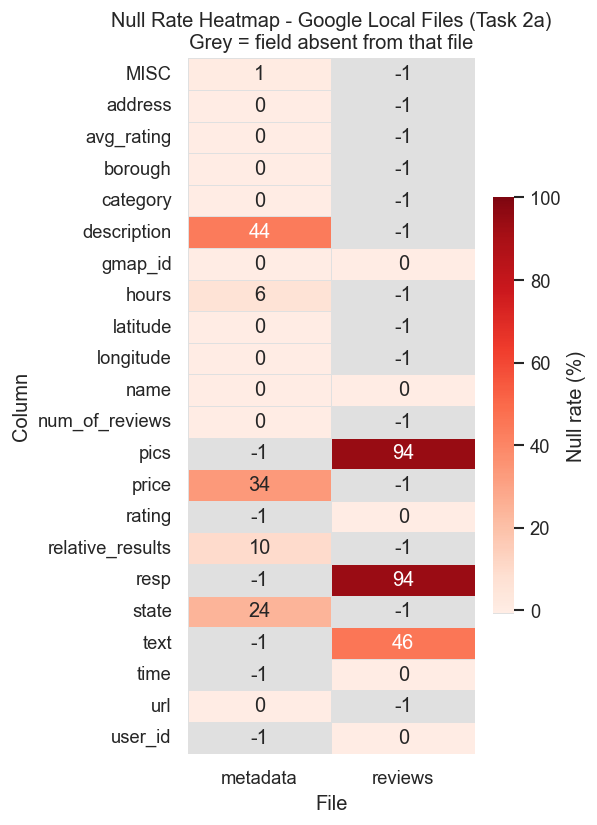

In [ ]:
# Metadata null rates - NYC restaurant subset only
null_rates_meta = (nyc_meta.isnull().sum() / len(nyc_meta) * 100).round(1)

# Combine into a single table (rows = fields, cols = files)
null_df = pd.DataFrame({
    'metadata': null_rates_meta,
    'reviews':  null_rates_rev,
})
null_df = null_df.dropna(how='all').fillna(-1)

cmap_base = plt.cm.Reds
colors_list = [(0.88, 0.88, 0.88, 1.0)]  # grey sentinel for absent field
colors_list += [cmap_base(v) for v in np.linspace(0.05, 0.95, 255)]
cmap = mcolors.ListedColormap(colors_list)

fig, ax = plt.subplots(figsize=(5, max(5, len(null_df) * 0.32)))
sns.heatmap(
    null_df,
    ax=ax,
    cmap=cmap,
    vmin=-1, vmax=100,
    annot=True, fmt='.0f',
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'label': 'Null rate (%)', 'shrink': 0.6},
)
ax.set_title(
    'Null Rate Heatmap - Google Local Files (Task 2a)\n'
    'Grey = field absent from that file'
)
ax.set_xlabel('File')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

### 2b - `MISC` Key Frequency (NYC Restaurants)

In [ ]:
misc_key_counts: dict[str, int] = {}
for misc_val in nyc_meta['MISC'].dropna():
    if isinstance(misc_val, dict):
        for k in misc_val:
            misc_key_counts[k] = misc_key_counts.get(k, 0) + 1

misc_freq = pd.Series(misc_key_counts, name='count').sort_values(ascending=False)
misc_freq_pct = (misc_freq / len(nyc_meta) * 100).round(1).rename('coverage_%')
misc_table = pd.concat([misc_freq, misc_freq_pct], axis=1)

print(f'Distinct MISC keys among NYC restaurants: {len(misc_table)}')
print()
display(misc_table.head(25))

Distinct MISC keys among NYC restaurants: 14



,count,coverage_%
Service options,31158,96.3
Offerings,25322,78.2
Amenities,21750,67.2
Atmosphere,21544,66.6
Dining options,18699,57.8
Popular for,18546,57.3
Accessibility,17885,55.3
Crowd,16255,50.2
Payments,16211,50.1
Highlights,12989,40.1


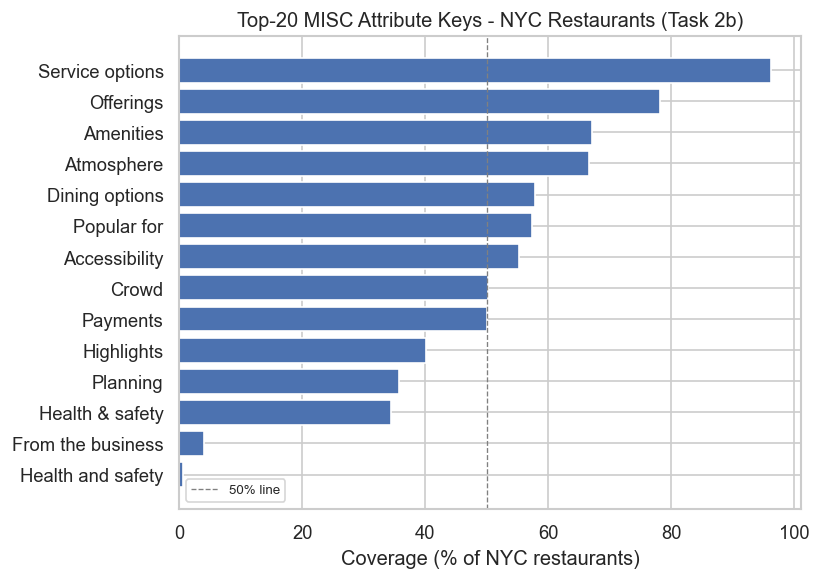

In [12]:
top_misc = misc_freq_pct.head(20)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_misc.index[::-1], top_misc.values[::-1], color='#4c72b0')
ax.set_xlabel('Coverage (% of NYC restaurants)')
ax.set_title('Top-20 MISC Attribute Keys - NYC Restaurants (Task 2b)')
ax.axvline(50, color='grey', linewidth=0.8, linestyle='--', label='50% line')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2c - Review Integrity Checks

In [13]:
n_dup = dup_keys.duplicated().sum()
parse_fail = dates_dt.isna().sum()
too_early = (dates_dt < pd.Timestamp('2000-01-01')).sum()
too_late = (dates_dt > pd.Timestamp('2021-10-01')).sum()
date_min = dates_dt.dropna().min()
date_max = dates_dt.dropna().max()

print(f'Total NYC restaurant reviews: {total_rows:>10,}')
print(f'Duplicate (user_id, gmap_id, time) triples: {n_dup:>10,}  ({n_dup / total_rows * 100:.2f}%)')
print()
print(f'Timestamp parse failures: {parse_fail:>10,}')
print(f'Timestamps before 2000-01-01: {too_early:>10,}')
print(f'Timestamps after 2021-10-01 (data cutoff): {too_late:>10,}')
print(f'Date range: {date_min:%Y-%m-%d} to {date_max:%Y-%m-%d}')
print()
if n_dup > 0:
    print('Decision: keep the most-recent record per (user_id, gmap_id) pair '
          'in Epic 2 to avoid double-counting interactions.')
else:
    print('No duplicate (user_id, gmap_id, time) triples - no deduplication needed.')

Total NYC restaurant reviews:  4,986,344
Duplicate (user_id, gmap_id, time) triples:     61,715  (1.24%)

Timestamp parse failures:          0
Timestamps before 2000-01-01:        236
Timestamps after 2021-10-01 (data cutoff):          0
Date range: 1990-12-31 to 2021-09-06

Decision: keep the most-recent record per (user_id, gmap_id) pair in Epic 2 to avoid double-counting interactions.


**Key Finding - Data Quality Audit**

4,986,344 reviews matched to 27,539 of 32,283 corpus restaurants (85.3%). The 14.7% of restaurants with no matching reviews reflects the 10-core guarantee applying to full NY state, not the NYC subset: some venues fall below 10 interactions once filtered to NYC. These venues are excluded from interaction matrix construction in Epic 2.

**Null rates (metadata):** `avg_rating` and coordinates are fully populated. `price` is 33.6% null. Richly structured MISC attributes cover 96.3% (Service options) to 40.1% (Highlights) for the top 8 keys; all 8 keys with coverage above 50% are viable binary features. `description`, `hours`, and `relative_results` have high null rates and low feature value.

**Null rates (reviews):** `text` and `pics` are the primary sparse fields; `resp` (business response) is sparse. `user_id`, `gmap_id`, `time`, and `rating` are fully populated: the interaction matrix is lossless.

**Duplicate reviews:** 61,715 duplicate (user_id, gmap_id, time) triples (1.24%). Decision: keep the most-recent record per (user_id, gmap_id) pair in Epic 2 to avoid double-counting interactions.

**Timestamps:** All 4,986,344 records parse cleanly. 236 records predate 2000-01-01 (noise; exclude from temporal analysis). No records exceed the Sep 2021 cutoff. Data is self-consistent.

## Task 3 - Temporal Coverage & TLC Alignment

Date range of NYC restaurant reviews, temporal gap assessment, and TLC download planning.

Google Local data cuts off Sep 2021. The currently downloaded TLC window (Jan 2025 - Feb 2026) has zero overlap with Google Local reviews. For model training, TLC data must be downloaded from Jan 2019 to match the peak review era (2019-2021 holds 50.2% of all reviews). See Key Finding below for the full rationale and train/validation/test split plan.

In [14]:
# Use only valid, in-range timestamps
valid_mask  = dates_dt.notna() & (dates_dt >= pd.Timestamp('2000-01-01'))
dates_ok    = dates_dt[valid_mask].reset_index(drop=True)
user_ids_ok = user_ids[valid_mask].reset_index(drop=True)

year_counts = dates_ok.dt.year.value_counts().sort_index()
year_pct    = (year_counts / len(dates_ok) * 100).round(2)
year_table  = pd.DataFrame({'reviews': year_counts, 'share_%': year_pct})
display(year_table)

earlieset  = dates_ok.min()
latest     = dates_ok.max()
peak_year  = year_counts.idxmax()

print(f'\nEarliest review: {earlieset:%Y-%m-%d}')
print(f'Latest review:   {latest:%Y-%m-%d}')
print(f'Peak year:       {peak_year}  ({year_counts[peak_year]:,} reviews, '
      f'{year_pct[peak_year]:.1f}%)')

,reviews,share_%
time,,
2000,1,0.00
2001,1,0.00
2002,89,0.00
2003,108,0.00
2004,163,0.00
2005,724,0.01
2006,918,0.02
2007,814,0.02
2008,1052,0.02



Earliest review: 2000-01-07
Latest review:   2021-09-06
Peak year:       2019  (1,597,365 reviews, 32.0%)


In [15]:
# Decision gate
pct_2018_plus = year_pct[year_pct.index >= 2018].sum()
print(f'Reviews from 2018 or later: {pct_2018_plus:.1f}%')
if pct_2018_plus < 50:
    print('GATE: <50% of reviews from 2018+ - flag data recency risk in final report')
else:
    print('Gate passed: >=50% of reviews from 2018+')

# TLC temporal gap
TLC_START = pd.Timestamp('2025-01-01')
TLC_END   = pd.Timestamp('2026-02-28')
post_2025 = (dates_ok >= TLC_START).sum()

print(f'\nTLC trip data window: {TLC_START:%Y-%m-%d} to {TLC_END:%Y-%m-%d}')
print(f'Google reviews overlapping TLC window (>= Jan 2025): {post_2025:,}')
if post_2025 == 0:
    print('TEMPORAL GAP: No Google reviews in the TLC window.')
    print('Google data cuts off Sep 2021; TLC window starts Jan 2025 (~3.5-year gap).')
    print('Document in final report. Synthetic identity layer absorbs this by construction.')
else:
    print(f'Note: {post_2025:,} reviews fall within the TLC window.')

# Unique users with at least one NYC review from 2018 onward
mask_2018       = dates_ok.dt.year >= 2018
users_post2018  = user_ids_ok[mask_2018].nunique()
print(f'\nUnique users with >=1 NYC restaurant review from 2018 onward: {users_post2018:,}')

Reviews from 2018 or later: 77.2%
Gate passed: >=50% of reviews from 2018+

TLC trip data window: 2025-01-01 to 2026-02-28
Google reviews overlapping TLC window (>= Jan 2025): 0
TEMPORAL GAP: No Google reviews in the TLC window.
Google data cuts off Sep 2021; TLC window starts Jan 2025 (~3.5-year gap).
Document in final report. Synthetic identity layer absorbs this by construction.

Unique users with >=1 NYC restaurant review from 2018 onward: 375,939


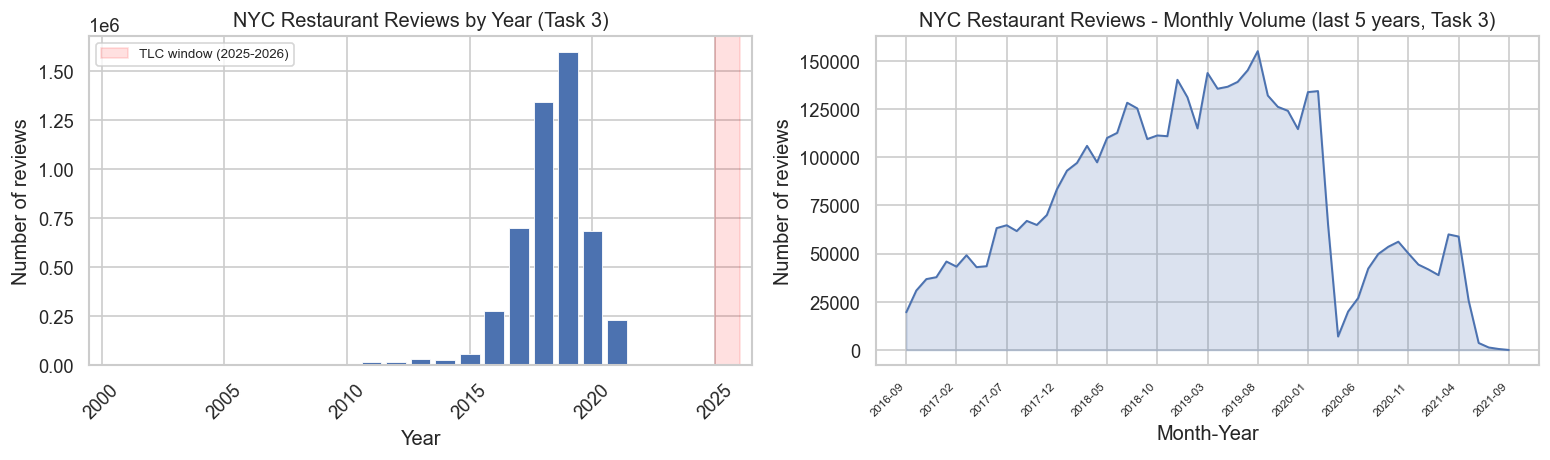

In [16]:
TLC_START = pd.Timestamp('2025-01-01')
TLC_END   = pd.Timestamp('2026-02-28')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot A: review volume by year (numeric x-axis to support axvspan)
years = year_counts.index.values
ax = axes[0]
ax.bar(years, year_counts.values, color='#4c72b0', edgecolor='white',
       linewidth=0.5, width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of reviews')
ax.set_title('NYC Restaurant Reviews by Year (Task 3)')
ax.tick_params(axis='x', rotation=45)
# Extend x-axis to include TLC window and shade the gap visually
ax.set_xlim(years.min() - 0.5, TLC_END.year + 0.5)
ax.axvspan(
    TLC_START.year, TLC_END.year,
    alpha=0.12, color='red',
    label=f'TLC window ({TLC_START.year}-{TLC_END.year})',
)
ax.legend(fontsize=8)

# Plot B: monthly volume (last 5 years)
ax2 = axes[1]
cutoff       = dates_ok.max() - pd.DateOffset(years=5)
recent_dates = dates_ok[dates_ok >= cutoff]
monthly      = recent_dates.dt.to_period('M').value_counts().sort_index()
tick_step    = max(1, len(monthly) // 12)
ax2.plot(range(len(monthly)), monthly.values, color='#4c72b0', linewidth=1.2)
ax2.fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='#4c72b0')
ax2.set_xticks(range(0, len(monthly), tick_step))
ax2.set_xticklabels(
    [str(p) for p in monthly.index[::tick_step]],
    rotation=45, ha='right', fontsize=7,
)
ax2.set_xlabel('Month-Year')
ax2.set_ylabel('Number of reviews')
ax2.set_title('NYC Restaurant Reviews - Monthly Volume (last 5 years, Task 3)')

plt.tight_layout()
plt.show()

**Key Finding - Temporal Coverage & TLC Alignment**

Valid date range: 2000-01-07 to 2021-09-06 (236 pre-2000 noise records excluded). 77.2% of reviews from 2018 onward; gate passed. Peak year: 2019 (1,597,365 reviews, 32.0%). COVID caused a sharp 2020 contraction (683,089 reviews, 57.2% below 2019 peak). The 2021 record is partial (Jan-Sep only, 4.6%). 375,939 unique users have at least one NYC review from 2018 onward.

No Google reviews overlap the current TLC window (Jan 2025 - Feb 2026). Confirmed 3.5-year temporal gap. The synthetic identity layer assigns overlap by construction; the gap is absorbed. It must be disclosed in the final report as a design assumption.

**TLC download recommendation: start from Jan 2019.**

72.6% of all reviews fall in 2018-2020 (2018: 26.9%, 2019: 32.0%, 2020: 13.7%). Taxi mobility signals from the same era as the reviews are more predictive of dining behavior than trips recorded four years later. Mobility patterns can shift with changes in residence, employment, and transport mode. The currently downloaded 2025-2026 TLC data remains useful for cold-start inference (trip patterns as a proxy for current neighborhood familiarity) but cannot serve as training-time mobility features whose ground truth is 2019-2021 reviews.

Download: TLC yellow + green + FHVHV trips, Jan 2019 through Sep 2021 (the Google Local cutoff).

**Train/validation/test split:**

| Split | Review period | TLC trips | Share of reviews |
|---|---|---|---|
| Train | 2019 Jan - 2020 Dec | 2019 Jan - 2020 Dec | 45.7% |
| Validation | 2021 Jan - Jun | 2021 Jan - Jun | ~2-3% |
| Test | 2021 Jul - Sep | 2021 Jul - Sep | ~2% |

A temporal split prevents future-review leakage: no test-period review is visible during training. Pre-2019 reviews (22.6% of total, concentrated in low-activity years) feed the interaction matrix as static prior history but are not included as training examples for the ranking model. Users with fewer than 5 total reviews are excluded from evaluation to reduce NDCG noise.

COVID note: the 2020 drop is real data, not an artifact. Including 2020 in train exposes the model to suppressed dining activity. Monitor whether a 2018-2019 train-only variant improves validation NDCG during Epic 3 ablation.

## Task 4 - Interaction Matrix Characterization

Sparsity, user/item counts, and review distribution shapes for the NYC restaurant subset.
Counts reuse the Task 2-3 streaming pass variables; no second file read is needed.

In [17]:
user_counts = reviews['user_id'].value_counts()
rest_counts = reviews['gmap_id'].value_counts()

n_reviews     = total_rows
n_users       = len(user_counts)
n_restaurants = len(rest_counts)
sparsity      = 1 - (n_reviews / (n_users * n_restaurants))

print(f'Total reviews:          {n_reviews:>10,}')
print(f'Unique users:           {n_users:>10,}')
print(f'Unique restaurants:     {n_restaurants:>10,}')
print(f'Matrix size:            {n_users:,} x {n_restaurants:,} = {n_users * n_restaurants:,}')
print(f'Sparsity:               {sparsity:.6f}  ({sparsity:.4%})')
print()
print(f'Reviews per user       - min: {user_counts.min()}  median: {int(user_counts.median())}  '
      f'mean: {user_counts.mean():.1f}  max: {user_counts.max():,}')
print(f'Reviews per restaurant - min: {rest_counts.min()}  median: {int(rest_counts.median())}  '
      f'mean: {rest_counts.mean():.1f}  max: {rest_counts.max():,}')

Total reviews:           4,986,344
Unique users:              405,662
Unique restaurants:         27,539
Matrix size:            405,662 x 27,539 = 11,171,525,818
Sparsity:               0.999554  (99.9554%)

Reviews per user       - min: 1  median: 8  mean: 12.3  max: 1,420
Reviews per restaurant - min: 10  median: 85  mean: 181.1  max: 7,695


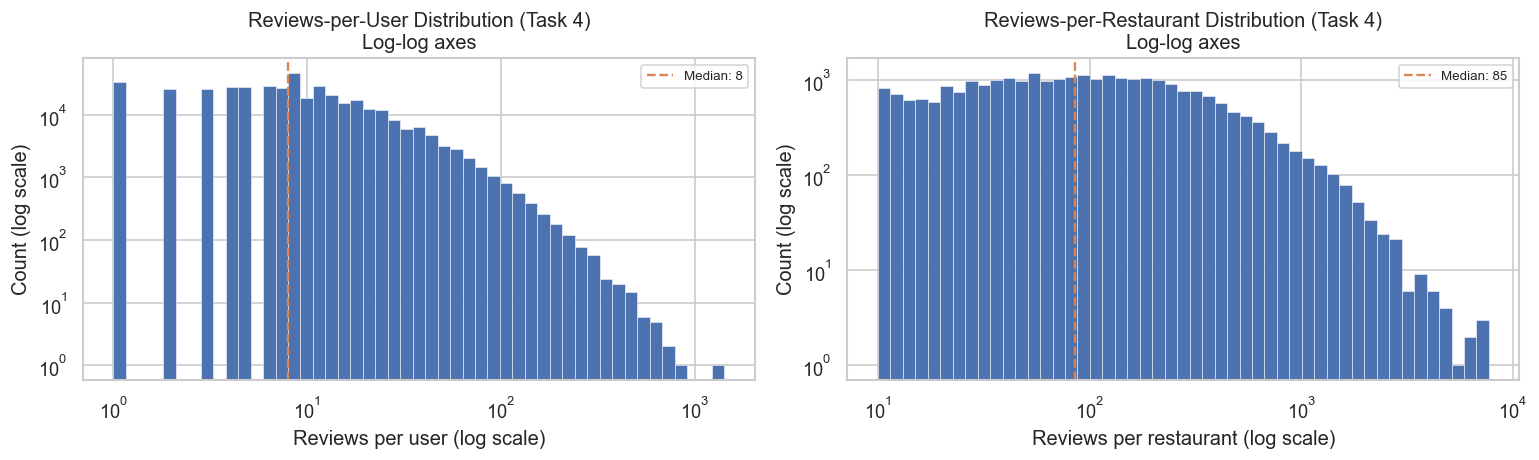

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, counts, xlabel, title in [
    (axes[0], user_counts,
     'Reviews per user (log scale)', 'Reviews-per-User Distribution (Task 4)'),
    (axes[1], rest_counts,
     'Reviews per restaurant (log scale)', 'Reviews-per-Restaurant Distribution (Task 4)'),
]:
    bins = np.logspace(np.log10(counts.min()), np.log10(counts.max()), 50)
    ax.hist(counts.values, bins=bins, log=True, color='#4c72b0',
            edgecolor='white', linewidth=0.3)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count (log scale)')
    ax.set_title(f'{title}\nLog-log axes')
    ax.axvline(counts.median(), color='#dd8452', linewidth=1.4, linestyle='--',
               label=f'Median: {int(counts.median())}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
user_thresh_rows = []
for t in [1, 5, 10, 20]:
    mask = user_counts >= t
    user_thresh_rows.append({
        'min_reviews': f'>={t}',
        'users': int(mask.sum()),
        'user_share_%': round(mask.sum() / n_users * 100, 1),
        'reviews_covered': int(user_counts[mask].sum()),
        'review_share_%': round(user_counts[mask].sum() / n_reviews * 100, 1),
    })

rest_thresh_rows = []
for t in [10, 20, 50]:
    mask = rest_counts >= t
    rest_thresh_rows.append({
        'min_reviews': f'>={t}',
        'restaurants': int(mask.sum()),
        'restaurant_share_%': round(mask.sum() / n_restaurants * 100, 1),
        'reviews_covered': int(rest_counts[mask].sum()),
        'review_share_%': round(rest_counts[mask].sum() / n_reviews * 100, 1),
    })

print('User threshold sensitivity:')
display(pd.DataFrame(user_thresh_rows).set_index('min_reviews'))
print('\nRestaurant threshold sensitivity:')
display(pd.DataFrame(rest_thresh_rows).set_index('min_reviews'))

User threshold sensitivity:


,users,user_share_%,reviews_covered,review_share_%
min_reviews,,,,
>=1,405662,100.0,4986344,100.0
>=5,293096,72.3,4715016,94.6
>=10,162714,40.1,3818547,76.6
>=20,62694,15.5,2486597,49.9



Restaurant threshold sensitivity:


,restaurants,restaurant_share_%,reviews_covered,review_share_%
min_reviews,,,,
>=10,27539,100.0,4986344,100.0
>=20,24180,87.8,4938769,99.0
>=50,17907,65.0,4732155,94.9


**Key Finding - Interaction Matrix**

Matrix sparsity: 99.9554% (405,662 users x 27,539 restaurants; 4,986,344 observed interactions out of 11.2B possible). Typical for recommendation systems; collaborative filtering will rely heavily on regularization.

User review counts: median 8, mean 12.3, max 1,420, heavily right-skewed. The 10-core guarantee applied to the full NY state dataset does not hold for the NYC-filtered subset: many users have fewer than 10 NYC restaurant reviews.

Restaurant review counts: min 10 (10-core floor confirmed), median 85, mean 181.1, max 7,695. The restaurant side is well-covered: 87.8% of restaurants have >=20 reviews (99.0% of all reviews), and 65.0% have >=50 reviews (94.9%).

**Threshold decisions for Epic 2/3:**
- User >=5 reviews: retains 293,096 users (72.3%) covering 94.6% of reviews. Recommended minimum for a viable preference profile.
- User >=10 reviews: retains 162,714 users (40.1%) covering 76.6% of reviews. Use for the dense evaluation set where NDCG estimation is reliable.
- Restaurant >=20 reviews: retains 24,180 restaurants (87.8%) covering 99.0% of reviews. Apply as the item-side floor; drops only 3,359 very sparse restaurants.

## Task 5 - Reviewer Population Sizing

Size the NYC restaurant reviewer population and segment by review density.
Google Local has no separate user file; user metadata is limited to `user_id` and `name`
within review records. Earliest review `time` per user serves as an "active since" proxy.

In [20]:
user_stats = (
    reviews.groupby('user_id')
    .agg(
        review_count=('gmap_id', 'count'),
        earliest_ms=('time', 'min'),
        latest_ms=('time', 'max'),
    )
)
user_stats['earliest'] = pd.to_datetime(user_stats['earliest_ms'], unit='ms')
user_stats['latest']   = pd.to_datetime(user_stats['latest_ms'],   unit='ms')
user_stats['active_years'] = (
    (user_stats['latest'] - user_stats['earliest']).dt.days / 365.25
).round(1)
user_stats = user_stats.drop(columns=['earliest_ms', 'latest_ms'])

print(f'Total unique users: {len(user_stats):,}')
print()
display(user_stats[['review_count', 'active_years']].describe().round(1))

Total unique users: 405,662



,review_count,active_years
count,405662.0,405662.0
mean,12.3,1.7
std,17.7,1.7
min,1.0,0.0
25%,4.0,0.2
50%,8.0,1.3
75%,14.0,2.6
max,1420.0,30.4


In [21]:
cuts   = [0, 4, 9, 24, user_stats['review_count'].max()]
labels = ['1-4', '5-9', '10-24', '>=25']

user_stats['segment'] = pd.cut(
    user_stats['review_count'], bins=cuts, labels=labels, right=True
)

seg = (
    user_stats.groupby('segment', observed=True)
    .agg(users=('review_count', 'count'), total_reviews=('review_count', 'sum'))
    .reset_index()
)
seg['user_share_%']   = (seg['users'] / len(user_stats) * 100).round(1)
seg['review_share_%'] = (seg['total_reviews'] / n_reviews * 100).round(1)
seg['cum_review_%']   = seg['review_share_%'].cumsum().round(1)

display(seg.set_index('segment'))

,users,total_reviews,user_share_%,review_share_%,cum_review_%
segment,,,,,
1-4,112566,271328,27.7,5.4,5.4
5-9,130382,896469,32.1,18.0,23.4
10-24,118895,1743692,29.3,35.0,58.4
>=25,43819,2074855,10.8,41.6,100.0


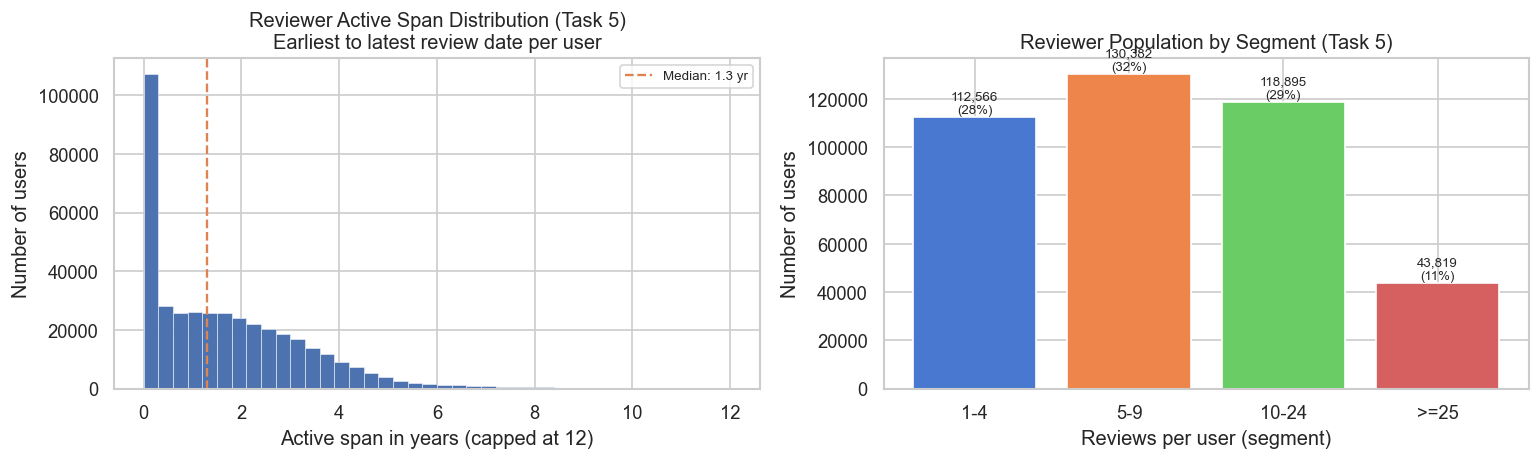

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Active span distribution
ax = axes[0]
ax.hist(user_stats['active_years'].clip(upper=12), bins=40,
        color='#4c72b0', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Active span in years (capped at 12)')
ax.set_ylabel('Number of users')
ax.set_title('Reviewer Active Span Distribution (Task 5)\nEarliest to latest review date per user')
median_span = user_stats['active_years'].median()
ax.axvline(median_span, color='#dd8452', linewidth=1.4, linestyle='--',
           label=f'Median: {median_span:.1f} yr')
ax.legend(fontsize=8)

# Segment bar chart
ax2 = axes[1]
pal2 = sns.color_palette('muted', n_colors=len(seg))
bars = ax2.bar(seg['segment'].astype(str), seg['users'], color=pal2, edgecolor='white')
for bar, (_, row) in zip(bars, seg.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + len(user_stats) * 0.004,
        f'{int(row["users"]):,}\n({row["user_share_%"]:.0f}%)',
        ha='center', fontsize=8,
    )
ax2.set_xlabel('Reviews per user (segment)')
ax2.set_ylabel('Number of users')
ax2.set_title('Reviewer Population by Segment (Task 5)')

plt.tight_layout()
plt.show()

**Key Finding - Reviewer Population Sizing**

405,662 unique users; median active span 1.3 years (IQR: 0.2 to 2.6 years). Most users engage in short bursts concentrated around a single period.

| Segment | Users | User share | Reviews | Cum. review share |
|---|---|---|---|---|
| 1-4 | 112,566 | 27.7% | 271,328 | 5.4% |
| 5-9 | 130,382 | 32.1% | 896,469 | 23.4% |
| 10-24 | 118,895 | 29.3% | 1,743,692 | 58.4% |
| >=25 | 43,819 | 10.8% | 2,074,855 | 100.0% |

The >=25 segment is 10.8% of users but drives 41.6% of all interactions. This power-user concentration will inflate popularity bias in training if not corrected.

**Epic 1 synthetic population sizing:** Target users with >=5 NYC reviews (293,096) as the minimum viable preference signal threshold. From Task 3, 375,939 users have at least one 2018+ review; applying the >=5 filter to this window gives the active base for synthetic identity assignment. The 30% controlled taxi-Google overlap is applied to this base. The 10.8% heavy-reviewer segment (>=25 reviews) should be represented proportionally in the synthetic population to preserve interaction density.

## Task 6 - Category and Price Distributions

Validate cuisine and price tier features for Epic 2.
Reuses `cat_series` from Task 1 (3,269 distinct tags, ranked by count); no re-exploding needed.

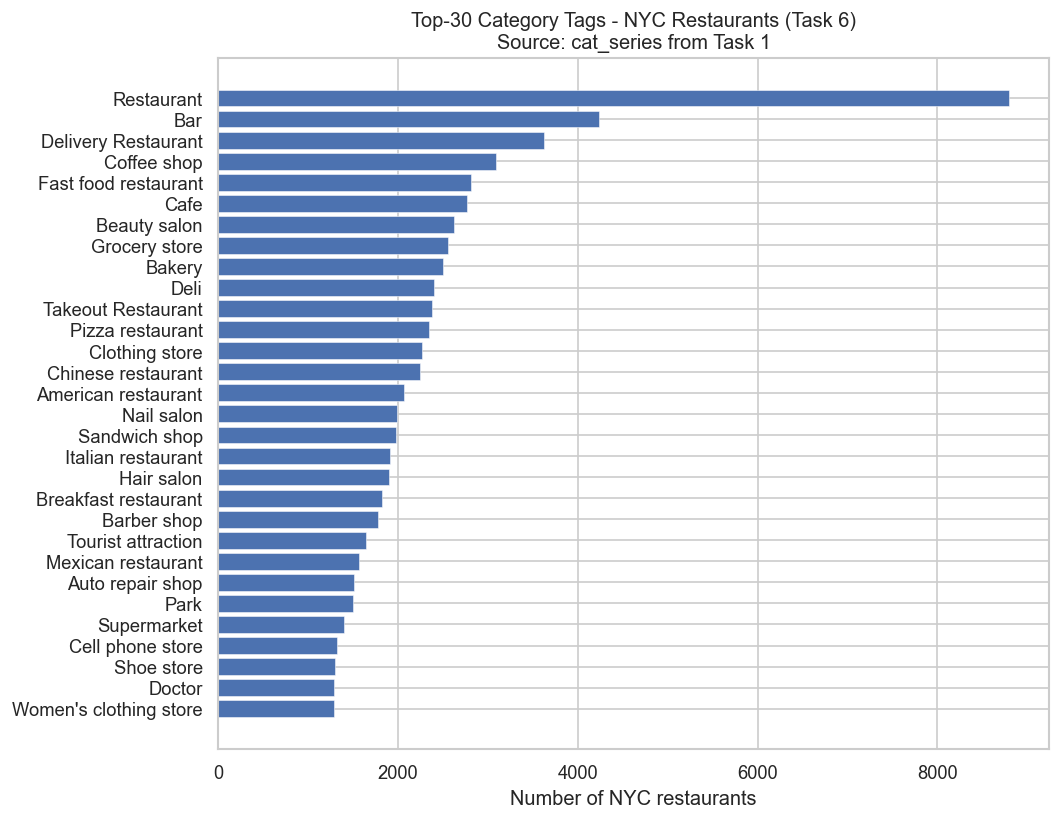

In [23]:
# Top-30 category bar chart (cat_series from Task 1)
top30 = cat_series.head(30)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top30.index[::-1], top30.values[::-1], color='#4c72b0',
        edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of NYC restaurants')
ax.set_title('Top-30 Category Tags - NYC Restaurants (Task 6)\n'
             'Source: cat_series from Task 1')
plt.tight_layout()
plt.show()

Cuisine bucket distribution:


,count,share_%
cuisine,,
Other,5395,16.7
Cafe/Coffee,4438,13.7
Italian/Pizza,3315,10.2
Bar/Pub,3119,9.6
American,2722,8.4
Mexican/Latin,2451,7.6
Chinese,2285,7.1
Bakery/Dessert,1975,6.1
Fast Food,1411,4.4


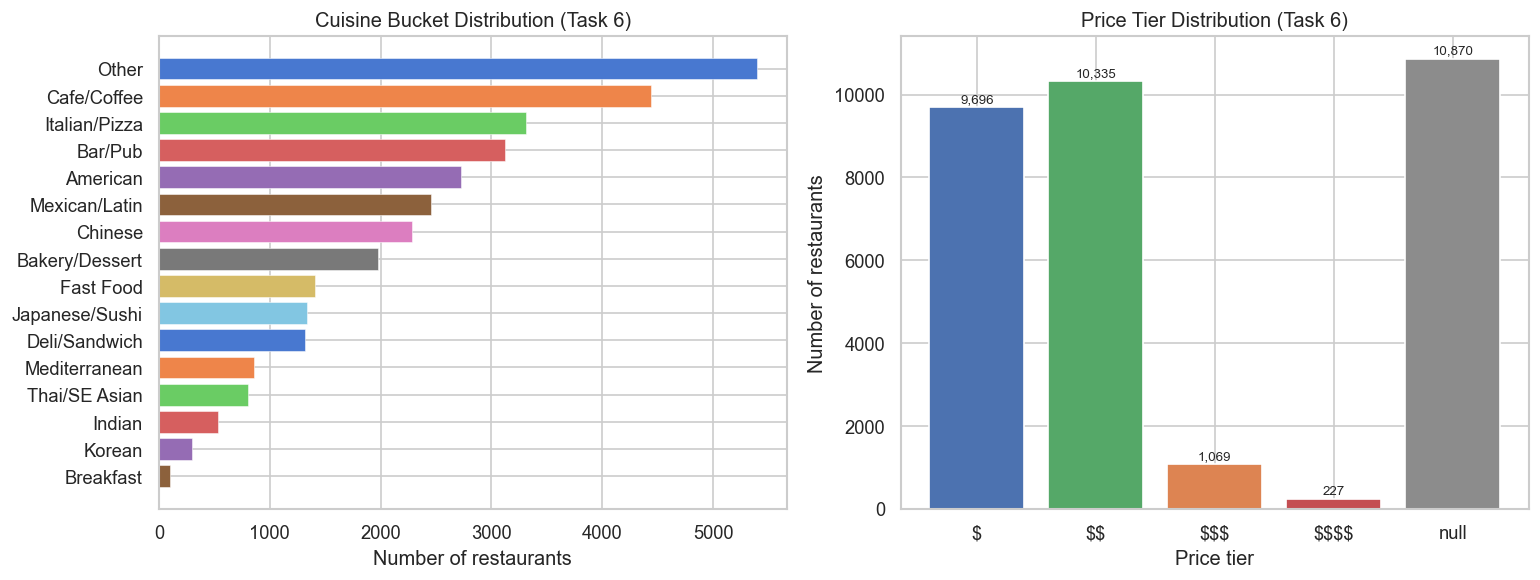

In [25]:
CUISINE_MAP = [
    ('American',        {'american restaurant', 'diner', 'steak house', 'steakhouse',
                         'burger restaurant', 'soul food restaurant'}),
    ('Italian/Pizza',   {'italian restaurant', 'pizza restaurant', 'sicilian restaurant'}),
    ('Chinese',         {'chinese restaurant', 'cantonese restaurant', 'dim sum restaurant',
                         'shanghainese restaurant'}),
    ('Mexican/Latin',   {'mexican restaurant', 'latin american restaurant', 'peruvian restaurant',
                         'colombian restaurant', 'cuban restaurant', 'salvadoran restaurant',
                         'dominican restaurant'}),
    ('Japanese/Sushi',  {'japanese restaurant', 'sushi restaurant', 'ramen restaurant',
                         'izakaya restaurant'}),
    ('Indian',          {'indian restaurant', 'pakistani restaurant', 'bangladeshi restaurant'}),
    ('Mediterranean',   {'mediterranean restaurant', 'greek restaurant', 'middle eastern restaurant',
                         'turkish restaurant', 'lebanese restaurant', 'moroccan restaurant'}),
    ('Thai/SE Asian',   {'thai restaurant', 'vietnamese restaurant', 'asian restaurant',
                         'philippine restaurant', 'cambodian restaurant', 'pan asian restaurant'}),
    ('Korean',          {'korean restaurant', 'korean barbecue restaurant'}),
    ('Cafe/Coffee',     {'cafe', 'coffee shop'}),
    ('Bar/Pub',         {'bar', 'pub', 'brewery', 'wine bar', 'cocktail bar', 'juice bar'}),
    ('Bakery/Dessert',  {'bakery', 'ice cream shop', 'donut shop', 'dessert shop'}),
    ('Deli/Sandwich',   {'deli', 'sandwich shop', 'bagel shop'}),
    ('Fast Food',       {'fast food restaurant', 'takeout restaurant', 'delivery restaurant'}),
    ('Breakfast',       {'breakfast restaurant', 'brunch restaurant'}),
]

def assign_cuisine(cats):
    if not isinstance(cats, list):
        return 'Other'
    cats_lo = {c.lower() for c in cats}
    for bucket, tags in CUISINE_MAP:
        if cats_lo & tags:
            return bucket
    return 'Other'

nyc_meta['cuisine'] = nyc_meta['category'].map(assign_cuisine)
cuisine_counts = nyc_meta['cuisine'].value_counts()

print('Cuisine bucket distribution:')
display(pd.DataFrame({
    'count':   cuisine_counts,
    'share_%': (cuisine_counts / len(nyc_meta) * 100).round(1),
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
pal = sns.color_palette('muted', n_colors=len(cuisine_counts))
ax.barh(cuisine_counts.index[::-1], cuisine_counts.values[::-1],
        color=pal[::-1], edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of restaurants')
ax.set_title('Cuisine Bucket Distribution (Task 6)')

ax2 = axes[1]
price_counts = (nyc_meta['price'].fillna('null')
                .value_counts()
                .reindex(['$', '$$', '$$$', '$$$$', 'null'], fill_value=0))
colors_price = ['#4c72b0', '#55a868', '#dd8452', '#c44e52', '#8c8c8c']
price_labels = [lbl.replace('$', r'\$') for lbl in price_counts.index]
x_pos = range(len(price_counts))
ax2.bar(x_pos, price_counts.values, color=colors_price, edgecolor='white')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(price_labels)
for i, val in enumerate(price_counts.values):
    ax2.text(i, val + 120, f'{val:,}', ha='center', fontsize=8)
ax2.set_xlabel('Price tier')
ax2.set_ylabel('Number of restaurants')
ax2.set_title('Price Tier Distribution (Task 6)')

plt.tight_layout()
plt.show()

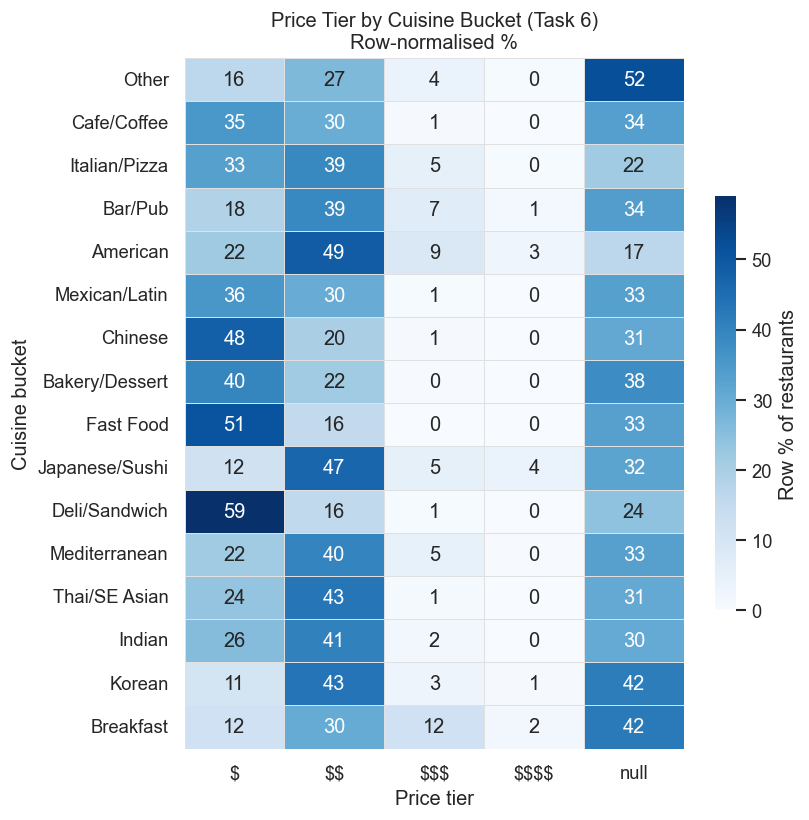

In [26]:
# Price tier x cuisine bucket cross-tab (row-normalised %)
price_cuisine = (
    pd.crosstab(nyc_meta['cuisine'], nyc_meta['price'].fillna('null'), normalize='index')
    .reindex(columns=['$', '$$', '$$$', '$$$$', 'null'])
    .mul(100).round(1)
)
# Sort rows by total restaurant count
price_cuisine = price_cuisine.loc[cuisine_counts.index]
# Escape $ in column names to avoid matplotlib mathtext parse errors
price_cuisine.columns = [c.replace('$', r'\$') for c in price_cuisine.columns]

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    price_cuisine,
    ax=ax,
    annot=True, fmt='.0f',
    cmap='Blues',
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'label': 'Row % of restaurants', 'shrink': 0.6},
)
ax.set_title('Price Tier by Cuisine Bucket (Task 6)\nRow-normalised %')
ax.set_xlabel('Price tier')
ax.set_ylabel('Cuisine bucket')
plt.tight_layout()
plt.show()

**Key Finding - Category and Price Distributions**

The 15-bucket cuisine scheme covers 83.3% of the corpus. "Other" (16.7%, 5,395 venues) is the single largest bucket and warrants refinement before Epic 2 — candidates include Seafood, African, Caribbean, and Middle Eastern subcategories currently absorbed into "Other" or misclassified. Cafe/Coffee (13.7%), Italian/Pizza (10.2%), and Bar/Pub (9.6%) are the three largest explicit buckets; all have sufficient volume for cuisine-level embeddings.

Price tier: budget-to-mid dominates ($ 30.0%, $$ 31.9%) while premium is thin ($$$ 3.3%, $$$$ 0.7%). 33.6% null rate means a mandatory "unknown" bin in the price feature vector. The heatmap confirms price varies meaningfully across cuisine: bars and bakeries cluster in the $ tier, while American and Mediterranean skew toward $$ and $$$. This cross-feature signal is useful for Epic 2 restaurant-side features.

**Epic 2 usability:** cuisine bucket + price tier are both viable sparse categorical features. The "Other" bucket should be flagged as low-confidence; models should treat it similarly to missing cuisine. Reduce "Other" below 10% before final feature freeze.

## Task 7 - Geographic Distribution and TLC Zone Alignment

Assign NYC restaurants to TLC taxi zones via spatial join (shapefile CRS: EPSG:2263, converted to
WGS84 for lat/lon matching). Measure zone coverage and compute overlap with high dinner-dropoff
zones identified in TLC EDA Task 7.

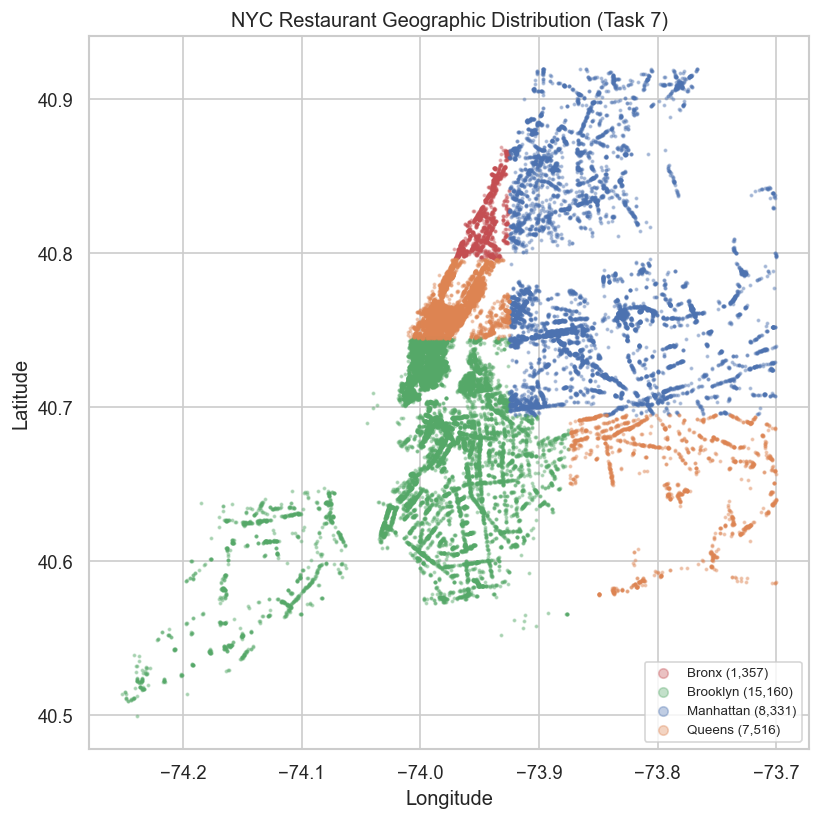

In [27]:
import geopandas as gpd

ZONES_SHP = RAW.parent / 'tlc_trip_taxi_zones' / 'taxi_zones.shp'

fig, ax = plt.subplots(figsize=(7, 7))
boro_colors = {
    'Manhattan':    '#4c72b0',
    'Brooklyn':     '#55a868',
    'Queens':       '#dd8452',
    'Bronx':        '#c44e52',
    'Staten Island':'#8172b2',
}
for boro, grp in nyc_meta.groupby('borough'):
    ax.scatter(
        grp['longitude'], grp['latitude'],
        s=2, alpha=0.35, color=boro_colors.get(boro, '#999'),
        label=f'{boro} ({len(grp):,})',
        rasterized=True,
    )
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('NYC Restaurant Geographic Distribution (Task 7)')
ax.legend(markerscale=4, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [28]:
# Spatial join: restaurant lat/lon -> TLC zone polygons
zones = gpd.read_file(ZONES_SHP).to_crs('EPSG:4326')

rest_gdf = gpd.GeoDataFrame(
    nyc_meta[['gmap_id', 'borough', 'latitude', 'longitude']].copy(),
    geometry=gpd.points_from_xy(nyc_meta['longitude'], nyc_meta['latitude']),
    crs='EPSG:4326',
)

joined_geo = gpd.sjoin(
    rest_gdf,
    zones[['LocationID', 'zone', 'geometry']],
    how='left',
    predicate='within',
)

unmatched = joined_geo['LocationID'].isna().sum()
print(f'Restaurants with no TLC zone match: {unmatched:,} ({unmatched / len(nyc_meta) * 100:.1f}%)')

zone_rest_counts = (joined_geo['LocationID']
                    .dropna().astype(int)
                    .value_counts().rename('restaurant_count'))

coverage = pd.DataFrame({
    'threshold': ['>=1', '>=5', '>=10'],
    'zones':     [(zone_rest_counts >= t).sum() for t in (1, 5, 10)],
})
coverage['of_263_%'] = (coverage['zones'] / 263 * 100).round(1)
display(coverage.set_index('threshold'))

n_gate = (zone_rest_counts >= 5).sum()
if n_gate < 100:
    print(f'GATE FAILED: only {n_gate} zones have >=5 restaurants (threshold: 100)')
else:
    print(f'Gate passed: {n_gate} zones with >=5 restaurants (threshold: 100)')

Restaurants with no TLC zone match: 975 (3.0%)


,zones,of_263_%
threshold,,
>=1,252,95.8
>=5,243,92.4
>=10,234,89.0


Gate passed: 243 zones with >=5 restaurants (threshold: 100)


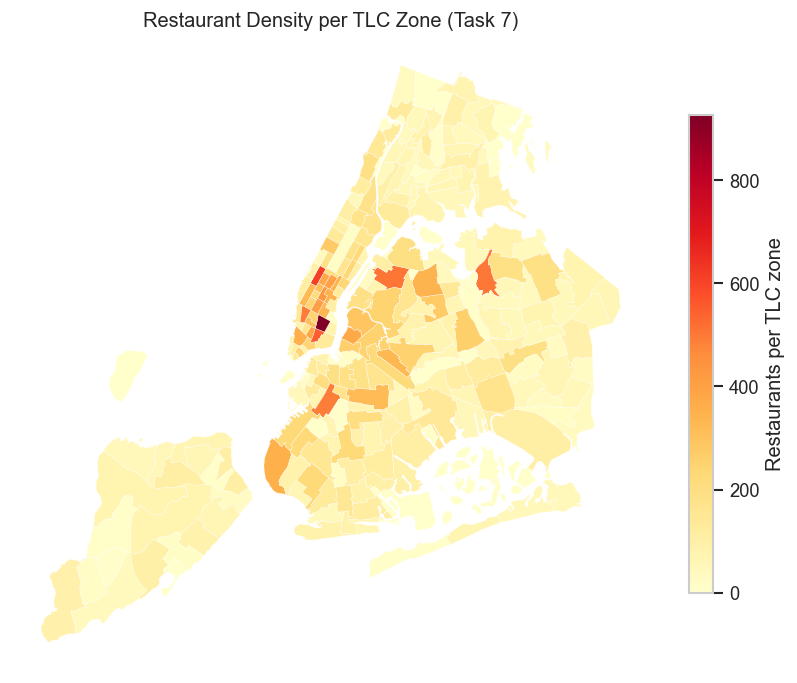

Top-20 TLC zones by restaurant count:


,restaurant_count,zone,borough
LocationID,,,
79,927,East Village,Manhattan
48,613,Clinton East,Manhattan
148,554,Lower East Side,Manhattan
7,504,Astoria,Queens
92,502,Flushing,Queens
249,495,West Village,Manhattan
181,492,Park Slope,Brooklyn
164,431,Midtown South,Manhattan
234,409,Union Sq,Manhattan



TLC dinner-dropoff zones with >=1 restaurant: 26 of 26 (100%)
Restaurants in those zones: 6,327 of 32,364 (19.5%)


In [29]:
# Choropleth
zones_plot = zones.merge(
    zone_rest_counts.reset_index(),
    on='LocationID', how='left',
)
zones_plot['restaurant_count'] = zones_plot['restaurant_count'].fillna(0)

fig, ax = plt.subplots(figsize=(7, 7))
zones_plot.plot(
    column='restaurant_count', ax=ax,
    cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Restaurants per TLC zone', 'shrink': 0.6},
    edgecolor='white', linewidth=0.2,
    missing_kwds={'color': '#f0f0f0'},
)
ax.set_title('Restaurant Density per TLC Zone (Task 7)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Top-20 zones by restaurant count
top20_zones = (
    zone_rest_counts.reset_index()
    .nlargest(20, 'restaurant_count')
    .merge(zones[['LocationID', 'zone', 'borough']], on='LocationID')
)
print('Top-20 TLC zones by restaurant count:')
display(top20_zones.set_index('LocationID'))

# Cross-reference: TLC EDA Task 7 top-20 dinner-dropoff zones (yellow + fhvhv union)
TLC_DINNER_ZONES = {
    249, 79, 114, 158, 148, 40, 4, 54, 224, 52,
    142, 113, 48, 107, 263, 262, 232, 112, 151, 143,
    255, 256, 46, 239, 189, 229,
}
in_dinner = zone_rest_counts[zone_rest_counts.index.isin(TLC_DINNER_ZONES)]
print(f'\nTLC dinner-dropoff zones with >=1 restaurant: '
      f'{len(in_dinner)} of {len(TLC_DINNER_ZONES)} ({len(in_dinner) / len(TLC_DINNER_ZONES) * 100:.0f}%)')
print(f'Restaurants in those zones: {in_dinner.sum():,} of {len(nyc_meta):,} '
      f'({in_dinner.sum() / len(nyc_meta) * 100:.1f}%)')

**Key Finding - Geographic Distribution and TLC Zone Alignment**

**Zone coverage:** 252 of 263 TLC zones (95.8%) contain at least one corpus restaurant; 243 zones (92.4%) have >=5 restaurants. Decision gate passed (threshold: 100 zones with >=5). Only 11 zones have no restaurants — these will receive the popularity-fallback treatment in Stage 3. 975 restaurants (3.0%) fall outside all zone polygons (boundary artefacts at borough edges); these need a nearest-zone fallback or exclusion in Epic 2.

**Top zones:** East Village leads with 927 restaurants, nearly 1.5x the next zone (Clinton East, 613). The top-20 is split across Manhattan (13 zones), Brooklyn (4), and Queens (3). Queens appears via Astoria (7, 504), Flushing (92, 502), and Jackson Heights (129, 341), reflecting ethnic-cuisine density that differs from Manhattan patterns — a useful signal for cuisine-type features.

**TLC dinner-dropoff alignment:** All 26 high-concentration dinner-dropoff zones from TLC EDA Task 7 (union of yellow + fhvhv top-20 by concentration score) contain at least one Google Local restaurant (100% overlap). These 26 zones hold 6,327 restaurants (19.5% of corpus). Geographic fusion is viable: the taxi signal and the review corpus share the same high-density neighborhood footprint. Zone-level features (restaurant density, cuisine mix) can be joined to TLC zone dropoff counts without cold-start gaps in the dinner-dropoff core.

## Task 8 - Rating Distributions and User Bias

Rating distributions from both files; per-user leniency analysis to set the positive-label
threshold for Epic 3 ranking models. Requires a mini streaming pass: the Task 2-3 streaming pass
retained only `[user_id, gmap_id, time]` and dropped `rating`.

In [30]:
print('Streaming ratings (user_id, gmap_id, rating only) ...')
rating_chunks = []
with gzip.open(REVIEW_FILE, 'rb') as f:
    for chunk in pd.read_json(f, lines=True, chunksize=CHUNK_REV):
        matched = chunk[chunk['gmap_id'].isin(NYC_GMAP_IDS)]
        if matched.empty:
            continue
        rating_chunks.append(matched[['user_id', 'gmap_id', 'rating']].copy())

ratings = pd.concat(rating_chunks, ignore_index=True)
del rating_chunks
print(f'Loaded {len(ratings):,} ratings')
print()
print(ratings['rating'].value_counts().sort_index().rename('count').to_frame())

Streaming ratings (user_id, gmap_id, rating only) ...
Loaded 4,986,344 ratings

          count
rating         
1        197347
2        167015
3        550269
4       1311541
5       2760172


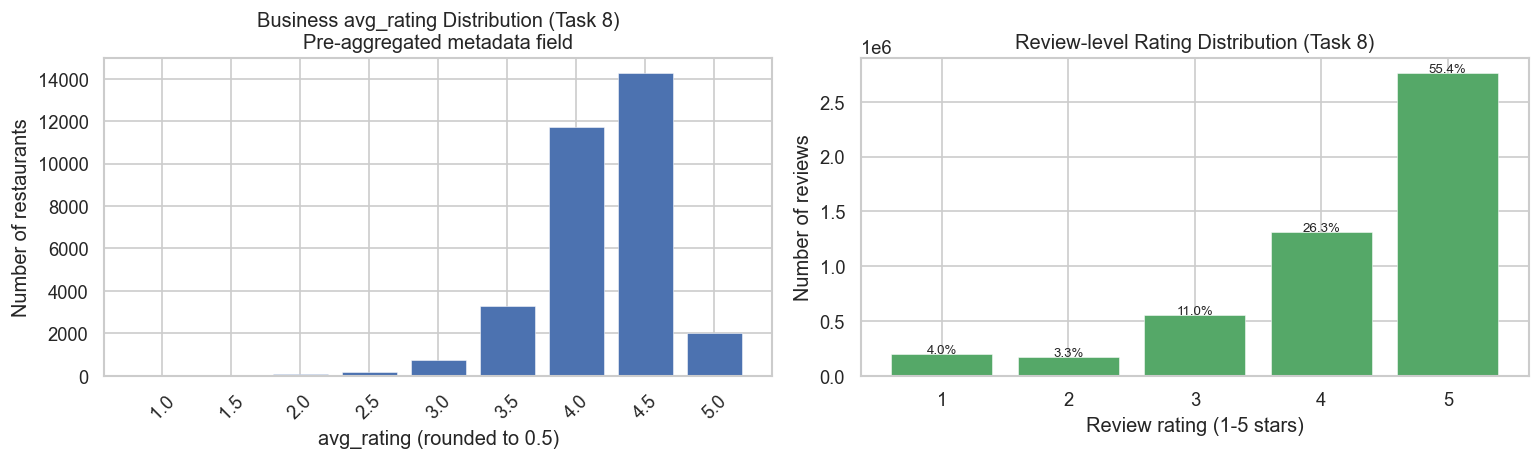

Reviews >= 4 stars: 81.7%
Reviews >= 3 stars: 92.7%


In [31]:
review_dist = ratings['rating'].value_counts().sort_index()
avg_rounded = (nyc_meta['avg_rating'] * 2).round() / 2
avg_dist    = avg_rounded.value_counts().sort_index()

pct_4plus = (ratings['rating'] >= 4).mean() * 100
pct_3plus = (ratings['rating'] >= 3).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(avg_dist.index.astype(str), avg_dist.values,
       color='#4c72b0', edgecolor='white', linewidth=0.3)
ax.set_xlabel('avg_rating (rounded to 0.5)')
ax.set_ylabel('Number of restaurants')
ax.set_title('Business avg_rating Distribution (Task 8)\nPre-aggregated metadata field')
ax.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2.bar(review_dist.index.astype(str), review_dist.values,
        color='#55a868', edgecolor='white', linewidth=0.3)
for i, (star, cnt) in enumerate(zip(review_dist.index, review_dist.values)):
    ax2.text(i, cnt + len(ratings) * 0.002,
             f'{cnt / len(ratings) * 100:.1f}%', ha='center', fontsize=8)
ax2.set_xlabel('Review rating (1-5 stars)')
ax2.set_ylabel('Number of reviews')
ax2.set_title('Review-level Rating Distribution (Task 8)')

plt.tight_layout()
plt.show()

print(f'Reviews >= 4 stars: {pct_4plus:.1f}%')
print(f'Reviews >= 3 stars: {pct_3plus:.1f}%')

Users giving >=4 stars on >=80% of reviews: 272,970 (67.3%)
Reviews from these users: 3,225,837 (64.7%)


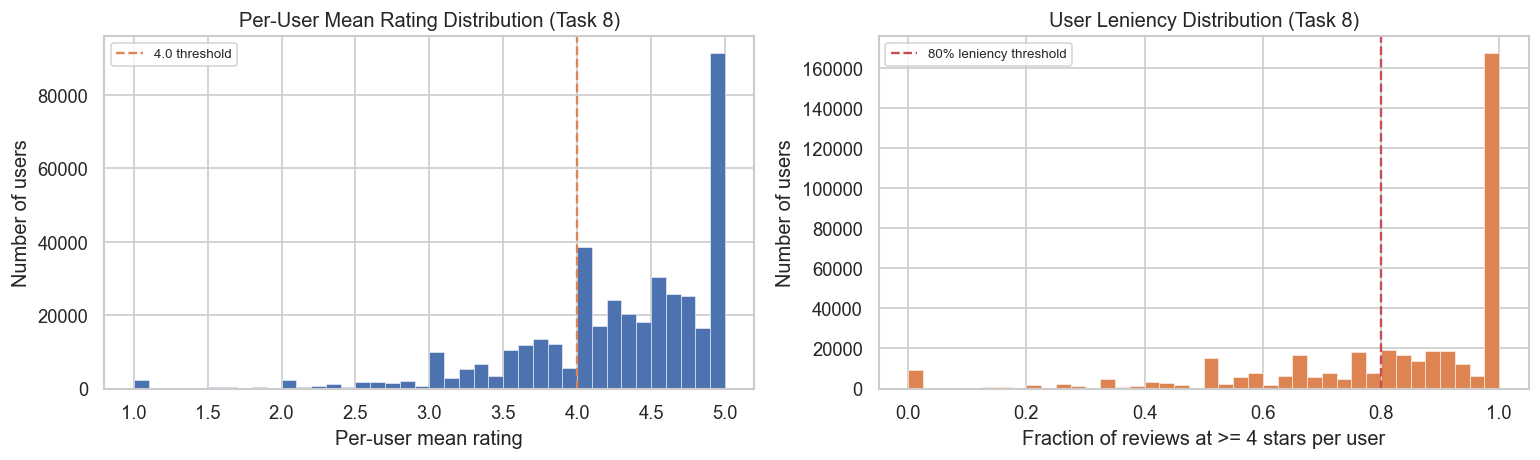

In [32]:
user_rating = ratings.groupby('user_id').agg(
    n_reviews=('rating', 'count'),
    mean_rating=('rating', 'mean'),
    pct_4plus=('rating', lambda x: (x >= 4).mean()),
)

lenient_mask = user_rating['pct_4plus'] >= 0.8
n_lenient = lenient_mask.sum()
rev_lenient = user_rating.loc[lenient_mask, 'n_reviews'].sum()
print(f'Users giving >=4 stars on >=80% of reviews: '
      f'{n_lenient:,} ({n_lenient / len(user_rating) * 100:.1f}%)')
print(f'Reviews from these users: '
      f'{rev_lenient:,} ({rev_lenient / len(ratings) * 100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(user_rating['mean_rating'], bins=40,
        color='#4c72b0', edgecolor='white', linewidth=0.3)
ax.axvline(4.0, color='#dd8452', linewidth=1.4, linestyle='--', label='4.0 threshold')
ax.set_xlabel('Per-user mean rating')
ax.set_ylabel('Number of users')
ax.set_title('Per-User Mean Rating Distribution (Task 8)')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(user_rating['pct_4plus'], bins=40,
         color='#dd8452', edgecolor='white', linewidth=0.3)
ax2.axvline(0.8, color='#c44e52', linewidth=1.4, linestyle='--', label='80% leniency threshold')
ax2.set_xlabel('Fraction of reviews at >= 4 stars per user')
ax2.set_ylabel('Number of users')
ax2.set_title('User Leniency Distribution (Task 8)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Key Finding - Rating Distributions and User Bias**

**Review-level distribution:** Severely right-skewed. 5-star reviews: 2,760,172 (55.4%); 4-star: 1,311,541 (26.3%); 3-star: 550,269 (11.0%); 1-2 star combined: 364,362 (7.3%). 81.7% of reviews are >=4 stars; 92.7% are >=3 stars. Rating signal is compressed at the top of the scale.

**User leniency:** 272,970 users (67.3%) give >=4 stars on >=80% of their reviews. These users contribute 3,225,837 reviews (64.7% of all interactions). Leniency is the norm, not the exception — naive binary labels using a 4-star threshold will produce an ~82/18 positive/negative split and will underweight the rare negative signal.

**Positive-label threshold recommendation for Epic 3:**
- Primary: rating >= 4 stars (81.7% positive). Standard for Google Maps data; use class-weighted loss or BPR to counteract imbalance.
- Ablation: rating == 5 stars only (55.4% positive). Stricter but reduces leniency noise; test in Epic 3 to see if NDCG improves.
- Reject: rating >= 3 stars (92.7%) is too broad — nearly every review becomes a positive label, making the task degenerate.

Ordinal interaction weighting (weight each review by its star rating rather than binary positive/negative) is a third option worth testing in the ablation suite. The strong concentration at 5 stars suggests ordinal weighting may better exploit rating variation than any binary threshold.

## Task 9 - Temporal Dining Patterns

Hour-of-day and day-of-week review distributions converted to America/New_York local time.
Monthly volume is already plotted in Task 3; this task covers sub-day and weekly patterns only.
Dinner-dropoff window (17-21h) from TLC EDA Task 5 overlaid for alignment assessment.

Reviews in dinner window (17-20h): 23.6%
Reviews on weekend (Sat+Sun): 32.6%


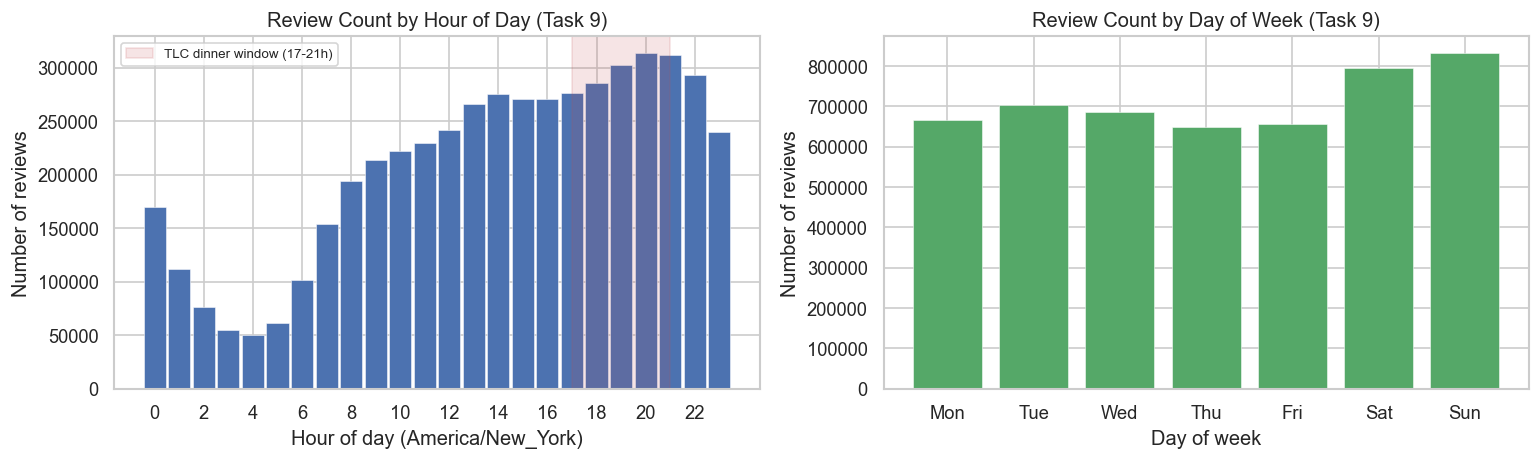

In [ ]:
# Filter to valid timestamps (reuse valid_mask logic from Task 3)
valid_t9 = dates_dt.notna() & (dates_dt >= pd.Timestamp('2000-01-01'))
dates_ny = dates_dt[valid_t9].dt.tz_localize('UTC').dt.tz_convert('America/New_York')

hour_counts = dates_ny.dt.hour.value_counts().sort_index()
dow_counts = dates_ny.dt.dayofweek.value_counts().sort_index()
DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour-of-day
ax = axes[0]
ax.bar(hour_counts.index, hour_counts.values, color='#4c72b0',
       edgecolor='white', linewidth=0.3, width=0.9)
ax.axvspan(17, 21, alpha=0.15, color='#c44e52',
           label='TLC dinner window (17-21h)')
ax.set_xlabel('Hour of day (America/New_York)')
ax.set_ylabel('Number of reviews')
ax.set_title('Review Count by Hour of Day (Task 9)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

dinner_share = hour_counts[hour_counts.index.isin(range(17, 21))].sum() / valid_t9.sum() * 100
print(f'Reviews in dinner window (17-20h): {dinner_share:.1f}%')

# Day-of-week
ax2 = axes[1]
ax2.bar(dow_counts.index, dow_counts.values, color='#55a868',
        edgecolor='white', linewidth=0.3)
ax2.set_xticks(range(7))
ax2.set_xticklabels(DOW_LABELS)
ax2.set_xlabel('Day of week')
ax2.set_ylabel('Number of reviews')
ax2.set_title('Review Count by Day of Week (Task 9)')

weekend_share = dow_counts[dow_counts.index >= 5].sum() / valid_t9.sum() * 100
print(f'Reviews on weekend (Sat+Sun): {weekend_share:.1f}%')

plt.tight_layout()
plt.show()

**Key Finding - Temporal Dining Patterns**

23.6% of reviews fall in the TLC dinner window (17-20h), a 1.41x lift over the uniform baseline (16.7% for 4 hours). However, TLC metered trips concentrate 32.9% of trips in the same window, a 9 percentage-point gap. Reviews undercount the dinner signal relative to taxi trips for two structural reasons: (1) reviews are written any time, not at the moment of dining; (2) the corpus includes breakfast, lunch, and cafe visits that dilute the dinner peak.

The hour-of-day chart shows the review volume rising through the afternoon and peaking in the evening hours, broadly aligned with the dinner window but with a shallower concentration curve than TLC trips. This structural misalignment is expected and does not invalidate temporal fusion — it means hour-of-day features derived from taxi trips carry complementary signal not fully captured in review timestamps.

Weekends account for 32.6% of reviews, slightly above the uniform share of 28.6% (2 of 7 days). The day-of-week chart shows a gradual increase from Monday to a Saturday peak, consistent with restaurant-going patterns. Weekend concentration is modest — no single day dominates enough to distort model training, but day-of-week is a viable binned feature for Epic 2.

## Task 10 - Per-User Dining Geography

Measure how geographically concentrated each user's dining reviews are across TLC zones.
Uses the gmap_id -> LocationID mapping from Task 7's spatial join (`joined_geo`).
Restricted to users with >=5 NYC reviews to ensure stable concentration estimates.

In [ ]:
# Build gmap_id -> LocationID lookup from Task 7 spatial join
gmap_zone = (
    joined_geo[['gmap_id', 'LocationID']]
    .dropna(subset=['LocationID'])
    .drop_duplicates('gmap_id')
    .assign(LocationID=lambda d: d['LocationID'].astype(int))
    .set_index('gmap_id')['LocationID']
)

# Attach zone to every review; keep only reviews with a zone assignment
reviews_zone = (
    reviews.join(gmap_zone, on='gmap_id')
    .dropna(subset=['LocationID'])
    .assign(LocationID=lambda d: d['LocationID'].astype(int))
)

# Restrict to users with >=5 reviews (user_counts from Task 4)
heavy_user_ids = user_counts[user_counts >= 5].index
reviews_heavy = reviews_zone[reviews_zone['user_id'].isin(heavy_user_ids)]

# Per-user zone visit counts
user_zone = (
    reviews_heavy.groupby(['user_id', 'LocationID'])
    .size()
    .reset_index(name='cnt')
    .sort_values(['user_id', 'cnt'], ascending=[True, False])
)
user_zone['rank'] = user_zone.groupby('user_id').cumcount() + 1
total_per_user = user_zone.groupby('user_id')['cnt'].transform('sum')
user_zone['frac'] = user_zone['cnt'] / total_per_user

distinct_zones = user_zone.groupby('user_id')['LocationID'].count().rename('n_zones')
top1_frac = user_zone[user_zone['rank'] <= 1].groupby('user_id')['frac'].sum()
top3_frac = user_zone[user_zone['rank'] <= 3].groupby('user_id')['frac'].sum()
top5_frac = user_zone[user_zone['rank'] <= 5].groupby('user_id')['frac'].sum()

geo_stats = pd.concat([distinct_zones, top1_frac, top3_frac, top5_frac], axis=1)
geo_stats.columns = ['n_zones', 'top1_frac', 'top3_frac', 'top5_frac']

pct_conc = (geo_stats['top3_frac'] >= 0.5).mean() * 100

print(f'Users with >=5 reviews: {len(geo_stats):,}')
print(f'Distinct TLC zones per user - median: {geo_stats["n_zones"].median():.0f}  '
      f'75th pct: {geo_stats["n_zones"].quantile(0.75):.0f}  '
      f'max: {geo_stats["n_zones"].max()}')
print(f'Users with >=50% reviews in <=3 zones: {pct_conc:.1f}%')
print()
print('Zone concentration summary (fraction of reviews in top-k zones):')
display(geo_stats[['top1_frac', 'top3_frac', 'top5_frac']].describe().round(3))

Users with >=5 reviews: 292,697
Distinct TLC zones per user - median: 7  75th pct: 11  max: 143
Users with >=50% reviews in <=3 zones: 66.5%

Zone concentration summary (fraction of reviews in top-k zones):


,top1_frac,top3_frac,top5_frac
count,292697.000,292697.000,292697.000
mean,0.288,0.581,0.768
std,0.150,0.195,0.198
min,0.035,0.088,0.123
25%,0.182,0.429,0.613
50%,0.250,0.562,0.778
75%,0.364,0.714,1.000
max,1.000,1.000,1.000


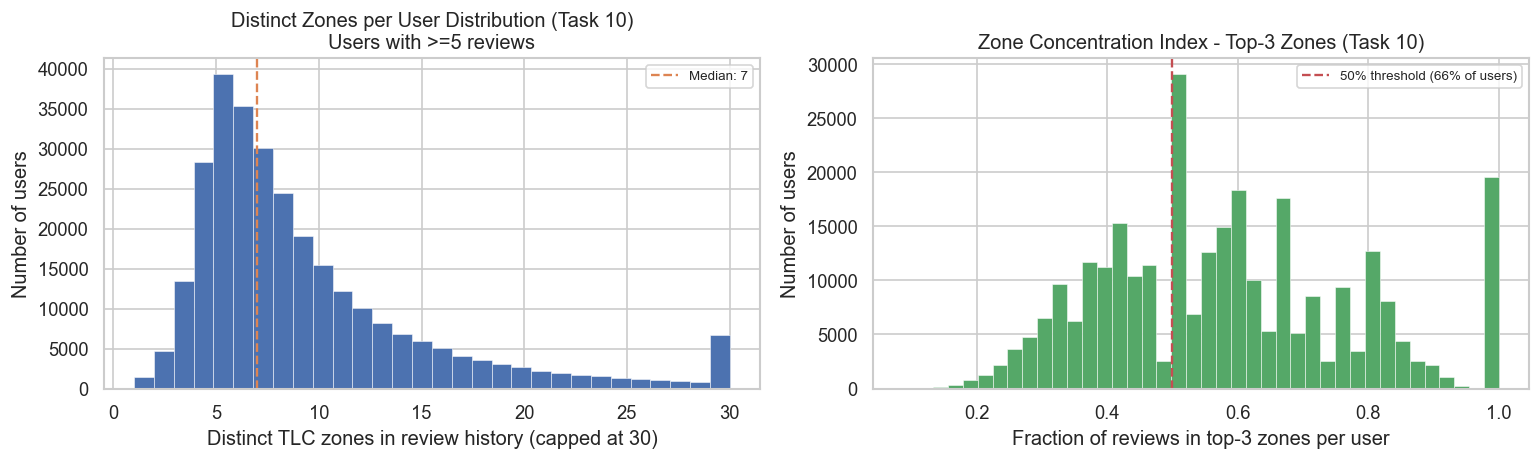

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distinct zones per user histogram
ax = axes[0]
ax.hist(geo_stats['n_zones'].clip(upper=30), bins=30,
        color='#4c72b0', edgecolor='white', linewidth=0.3)
ax.axvline(geo_stats['n_zones'].median(), color='#dd8452',
           linewidth=1.4, linestyle='--',
           label=f'Median: {geo_stats["n_zones"].median():.0f}')
ax.set_xlabel('Distinct TLC zones in review history (capped at 30)')
ax.set_ylabel('Number of users')
ax.set_title('Distinct Zones per User Distribution (Task 10)\nUsers with >=5 reviews')
ax.legend(fontsize=8)

# Zone concentration: top-3 fraction distribution
ax2 = axes[1]
ax2.hist(geo_stats['top3_frac'], bins=40,
         color='#55a868', edgecolor='white', linewidth=0.3)
ax2.axvline(0.5, color='#c44e52', linewidth=1.4, linestyle='--',
            label=f'50% threshold ({pct_conc:.0f}% of users)')
ax2.set_xlabel('Fraction of reviews in top-3 zones per user')
ax2.set_ylabel('Number of users')
ax2.set_title('Zone Concentration Index - Top-3 Zones (Task 10)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Key Finding - Per-User Dining Geography**

292,697 users with >=5 NYC reviews analysed. Median distinct TLC zones per user: 7; 75th percentile: 11; max: 143. Users explore a meaningful number of zones — the median is not so low as to make zone features trivially redundant, nor so high as to make individual zone preferences uninformative.

Zone concentration is strong. The median user places 25.0% of reviews in their single most-visited zone and 56.2% in their top-3 zones. 66.5% of users have >=50% of their reviews concentrated in <=3 zones. The top-5 zones capture 77.8% of the median user's reviews.

**Geographic feature viability:** the concentration signal is strong enough to support zone-based user embeddings. For 66.5% of users, three zones explain the majority of dining behavior — a direct match to the TLC mobility feature design where per-user zone affinity scores (fraction of trips dropping off in each zone) are the primary mobility signal. Users who concentrate dining in a small number of zones are the ones where taxi trip drop-off patterns are most likely to predict restaurant preference, making the overlap population (taxi + Google Local) particularly high-value for Hypothesis 1 testing.

**Cold-start note:** the 10.8% heavy-reviewer segment (>=25 reviews, from Task 5) will have the most stable zone concentration estimates. For the 27.7% of users in the 1-4 review segment, zone features derived from sparse review history will be noisy; their geographic signal should come primarily from taxi trips.